# 🛠️ Feature Engineering — Credit Risk Dataset
---
### *Transforming raw data into powerful predictive features*

## 📦 1. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Styling
sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 2. Load Dataset

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
print(f'✅ Dataset loaded!')
print(f'📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

✅ Dataset loaded!
📊 Shape: 32581 rows × 12 columns


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3


## 🧹 3. Handle Missing Values

In [3]:
# Before imputation
missing_before = df.isnull().sum()
print('🔴 Missing values BEFORE imputation:')
print(missing_before[missing_before > 0].to_string())

# Fill missing values with median
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# After imputation
missing_after = df.isnull().sum()
print('\n✅ Missing values AFTER imputation (median):')
print(f'Total missing: {missing_after.sum()}')

🔴 Missing values BEFORE imputation:
person_emp_length     895
loan_int_rate        3116

✅ Missing values AFTER imputation (median):
Total missing: 0


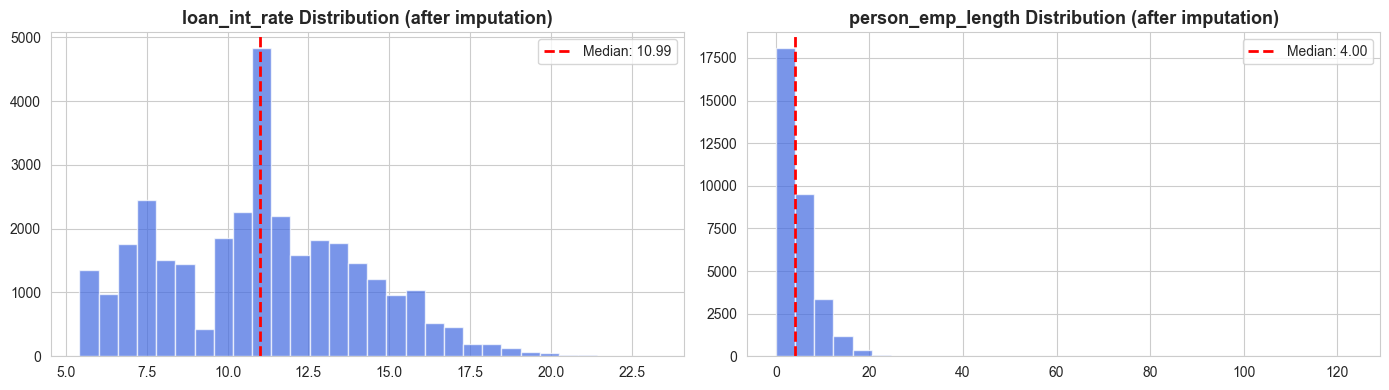

✅ Missing values handled successfully!


In [4]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i, col in enumerate(['loan_int_rate', 'person_emp_length']):
    axes[i].hist(df[col].dropna(), bins=30, color='royalblue', edgecolor='white', alpha=0.7)
    axes[i].axvline(df[col].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(f'{col} Distribution (after imputation)', fontsize=13, fontweight='bold')
    axes[i].legend()

plt.tight_layout()
plt.show()
print('✅ Missing values handled successfully!')

## 🔍 4. Remove Invalid Outliers

In [5]:
# Before removal
before_count = len(df)
print(f'📊 Records before cleaning: {before_count}')

# Remove unrealistic ages
age_outliers = df[df['person_age'] >= 90].shape[0]
df = df[df['person_age'] < 90]
print(f'🟡 Removed {age_outliers} records with age >= 90')

# Remove unrealistic employment length (> age - 10)
emp_outliers = df[df['person_emp_length'] >= df['person_age'] - 10].shape[0]
df = df[df['person_emp_length'] < df['person_age'] - 10]
print(f'🟡 Removed {emp_outliers} records with emp_length >= age - 10')

# After removal
after_count = len(df)
print(f'📊 Records after cleaning: {after_count}')
print(f'✅ Total removed: {before_count - after_count} ({round((before_count-after_count)/before_count*100, 2)}%)')

📊 Records before cleaning: 32581
🟡 Removed 6 records with age >= 90
🟡 Removed 2 records with emp_length >= age - 10
📊 Records after cleaning: 32573
✅ Total removed: 8 (0.02%)


## 🏗️ 5. Create New Features

In [6]:
# Income groups
df['income_group'] = pd.cut(df['person_income'], 
                            bins=[0, 25000, 50000, 75000, 100000, float('inf')],
                            labels=['low', 'l-middle', 'middle', 'h-middle', 'high'])

# Loan amount groups
df['loan_amnt_group'] = pd.cut(df['loan_amnt'],
                               bins=[0, 10000, 15000, float('inf')],
                               labels=['small', 'medium', 'large'])

# Loan to income ratio
df['loan_to_income'] = df['loan_amnt'] / df['person_income']

# Debt to income ratio (loan_percent_income already exists, but we keep consistent naming)
df['debt_to_income'] = df['loan_percent_income']

# Age group
df['age_group'] = pd.cut(df['person_age'],
                         bins=[0, 25, 35, 50, 100],
                         labels=['young', 'mid_young', 'middle_age', 'senior'])

# Employment length category
df['emp_length_group'] = pd.cut(df['person_emp_length'],
                                bins=[-1, 1, 3, 7, 15, float('inf')],
                                labels=['new', 'junior', 'mid', 'senior', 'veteran'])

print('✅ New features created successfully!')
print(f'📊 Dataset now has {len(df.columns)} columns')
print('\n🔷 New columns:')
new_cols = ['income_group', 'loan_amnt_group', 'loan_to_income', 
            'debt_to_income', 'age_group', 'emp_length_group']
for col in new_cols:
    print(f'   • {col}')

✅ New features created successfully!
📊 Dataset now has 18 columns

🔷 New columns:
   • income_group
   • loan_amnt_group
   • loan_to_income
   • debt_to_income
   • age_group
   • emp_length_group


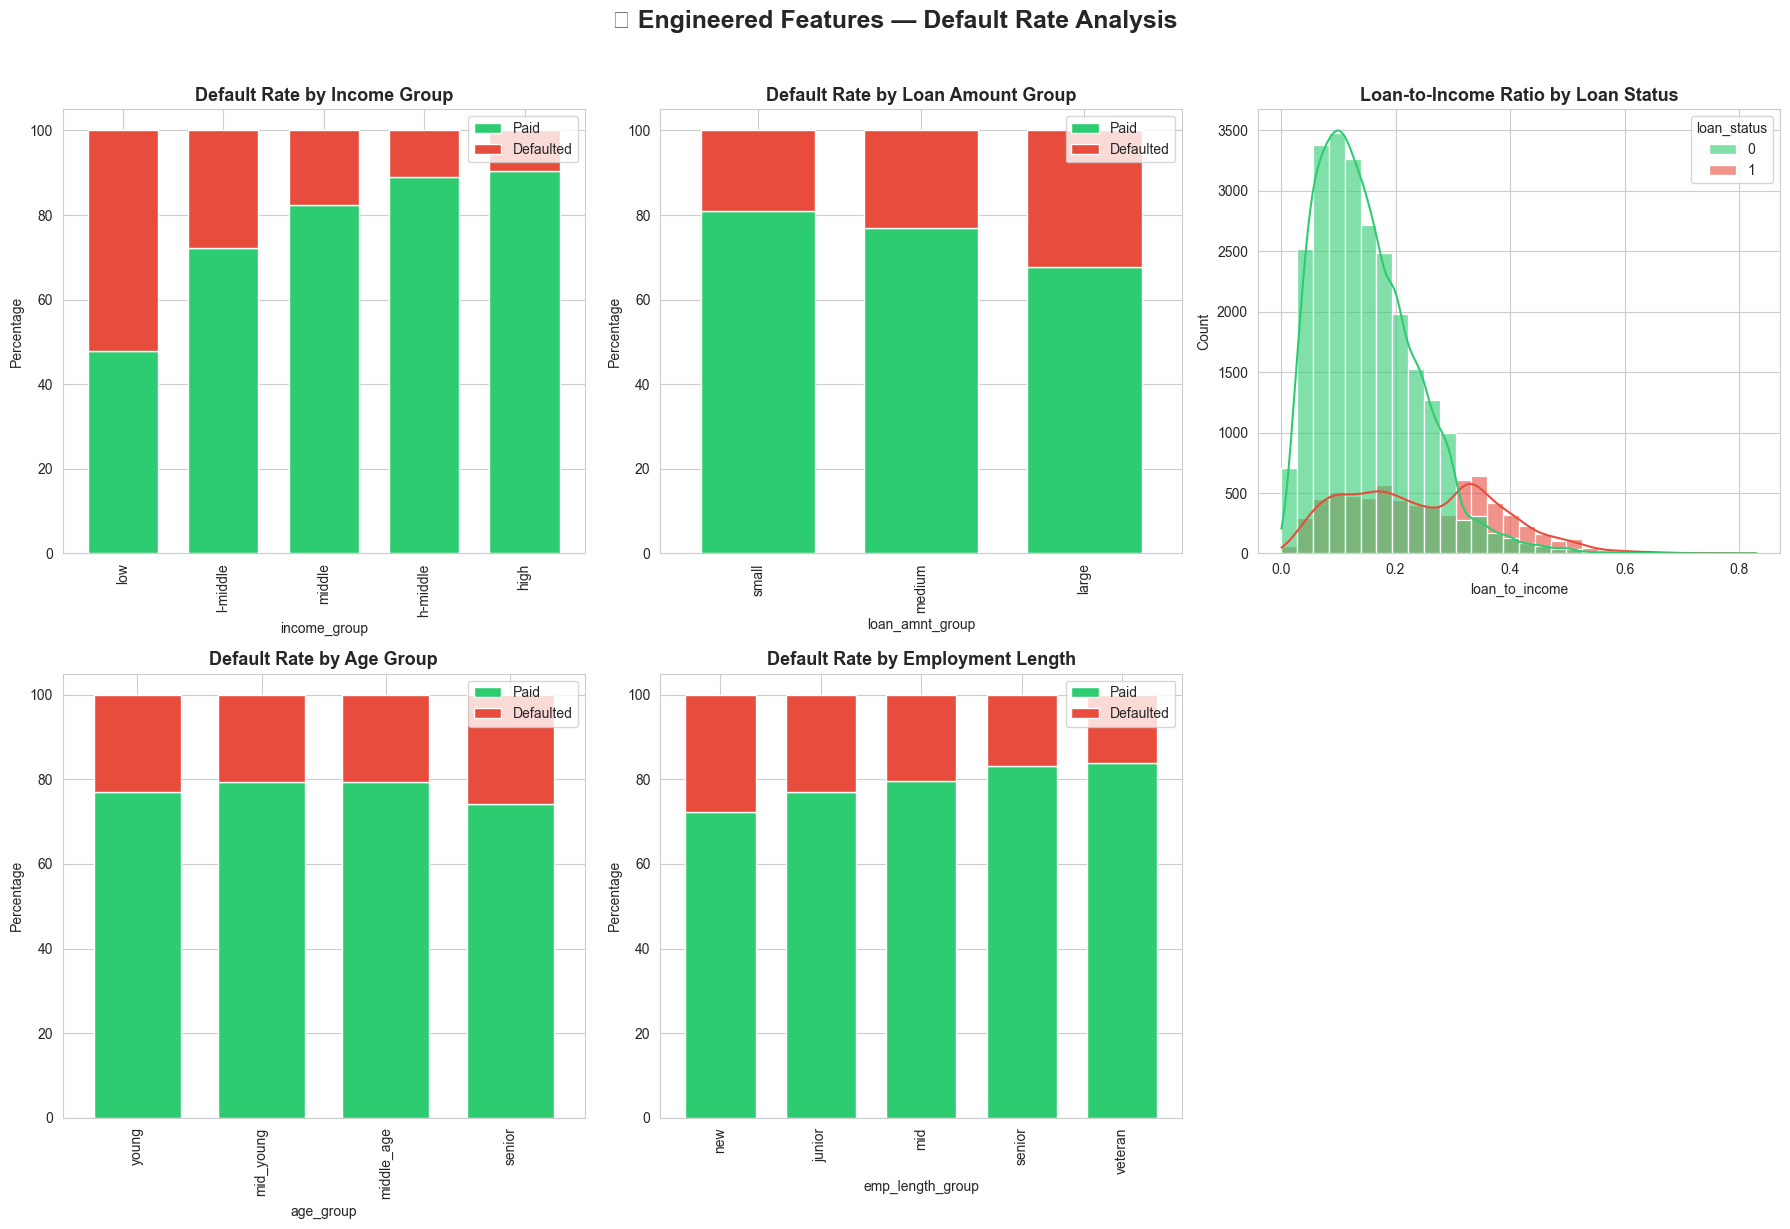

In [7]:
# Visualize new engineered features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Income group vs loan status
income_ct = pd.crosstab(df['income_group'], df['loan_status'], normalize='index') * 100
income_ct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[0], width=0.7)
axes[0].set_title('Default Rate by Income Group', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].legend(['Paid', 'Defaulted'])

# Loan amount group vs loan status
loan_ct = pd.crosstab(df['loan_amnt_group'], df['loan_status'], normalize='index') * 100
loan_ct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[1], width=0.7)
axes[1].set_title('Default Rate by Loan Amount Group', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage')
axes[1].legend(['Paid', 'Defaulted'])

# Loan to income distribution
sns.histplot(df, x='loan_to_income', hue='loan_status', kde=True, 
            palette=['#2ecc71', '#e74c3c'], bins=30, alpha=0.6, ax=axes[2])
axes[2].set_title('Loan-to-Income Ratio by Loan Status', fontsize=13, fontweight='bold')

# Age group vs default
age_ct = pd.crosstab(df['age_group'], df['loan_status'], normalize='index') * 100
age_ct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[3], width=0.7)
axes[3].set_title('Default Rate by Age Group', fontsize=13, fontweight='bold')
axes[3].set_ylabel('Percentage')
axes[3].legend(['Paid', 'Defaulted'])

# Employment length group vs default
emp_ct = pd.crosstab(df['emp_length_group'], df['loan_status'], normalize='index') * 100
emp_ct.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=axes[4], width=0.7)
axes[4].set_title('Default Rate by Employment Length', fontsize=13, fontweight='bold')
axes[4].set_ylabel('Percentage')
axes[4].legend(['Paid', 'Defaulted'])

# Hide the 6th subplot (or show another)
axes[5].axis('off')

plt.suptitle('📊 Engineered Features — Default Rate Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🔢 6. Encode Categorical Variables

In [8]:
# Separate features and target
y = df['loan_status']
X = df.drop(['loan_status'], axis=1)

print(f'🎯 Target variable shape: {y.shape}')
print(f'📋 Feature matrix shape: {X.shape}')

# Identify columns to encode
label_encode_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 
                     'cb_person_default_on_file', 'income_group', 'loan_amnt_group',
                     'age_group', 'emp_length_group']

print('\n🔷 Columns to encode:')
for col in label_encode_cols:
    print(f'   • {col} ({X[col].nunique()} unique values)')

# Apply label encoding
label_encoder = LabelEncoder()
for col in label_encode_cols:
    X[col] = label_encoder.fit_transform(X[col])

print('\n✅ Label encoding completed!')

🎯 Target variable shape: (32573,)
📋 Feature matrix shape: (32573, 17)

🔷 Columns to encode:
   • person_home_ownership (4 unique values)
   • loan_intent (6 unique values)
   • loan_grade (7 unique values)
   • cb_person_default_on_file (2 unique values)
   • income_group (5 unique values)
   • loan_amnt_group (3 unique values)
   • age_group (4 unique values)
   • emp_length_group (5 unique values)

✅ Label encoding completed!


In [9]:
# Apply One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=label_encode_cols, prefix=label_encode_cols)

print(f'✅ One-Hot Encoding completed!')
print(f'📊 Shape after encoding: {X_encoded.shape[0]} rows × {X_encoded.shape[1]} columns')
print(f'\n🔷 Sample of encoded features:')
X_encoded.head(2)

✅ One-Hot Encoding completed!
📊 Shape after encoding: 32573 rows × 45 columns

🔷 Sample of encoded features:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_to_income,debt_to_income,person_home_ownership_0,...,loan_amnt_group_2,age_group_0,age_group_1,age_group_2,age_group_3,emp_length_group_0,emp_length_group_1,emp_length_group_2,emp_length_group_3,emp_length_group_4
1,21,9600,5.0,1000,11.14,0.10,2,0.104167,0.10,False,...,True,False,False,False,True,False,True,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,0.572917,0.57,True,...,True,False,False,False,True,False,False,True,False,False


## ⚖️ 7. Feature Scaling

✅ Feature scaling completed (StandardScaler)

📊 Before scaling (sample):
Mean: 27.7164, Std: 6.1942

📊 After scaling (sample):
Mean: 0.0000, Std: 1.0000


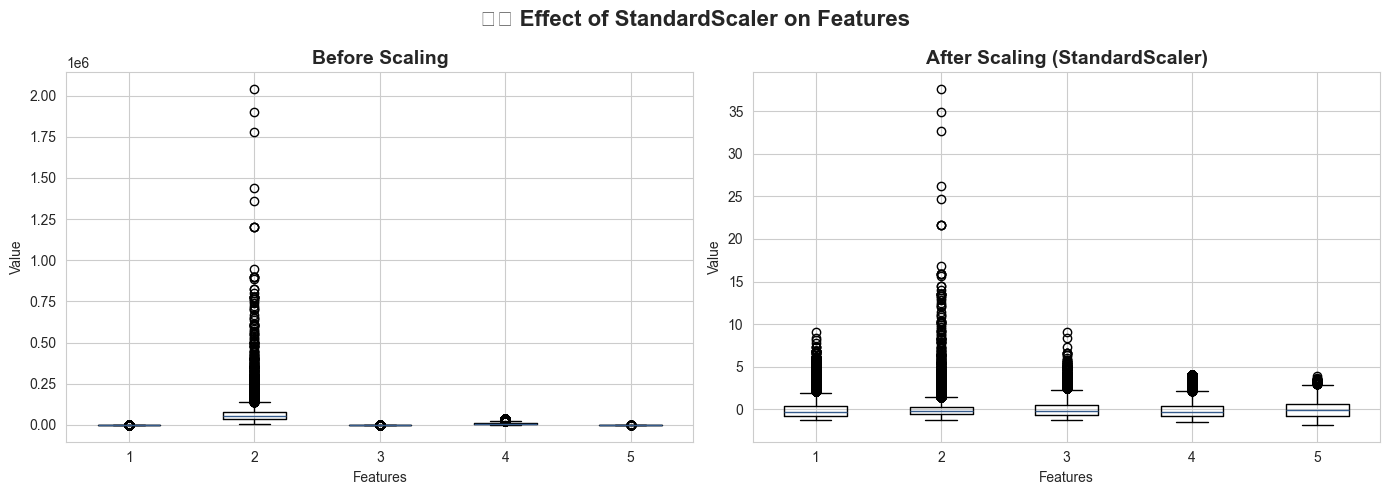

In [10]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print('✅ Feature scaling completed (StandardScaler)')
print(f'\n📊 Before scaling (sample):')
print(f'Mean: {X_encoded.iloc[:, 0].mean():.4f}, Std: {X_encoded.iloc[:, 0].std():.4f}')
print(f'\n📊 After scaling (sample):')
print(f'Mean: {X_scaled.iloc[:, 0].mean():.4f}, Std: {X_scaled.iloc[:, 0].std():.4f}')

# Visualize scaling effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(X_encoded.iloc[:, :5])
axes[0].set_title('Before Scaling', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Value')

axes[1].boxplot(X_scaled.iloc[:, :5])
axes[1].set_title('After Scaling (StandardScaler)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Value')

plt.suptitle('⚖️ Effect of StandardScaler on Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## ✂️ 8. Train-Test Split

In [11]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=0, stratify=y
)

print('✅ Train-test split completed!')
print(f'📊 Training set: {X_train.shape[0]} samples')
print(f'📊 Test set: {X_test.shape[0]} samples')
print(f'\n🎯 Target distribution in training set:')
print(y_train.value_counts(normalize=True).mul(100).round(1).to_string())
print(f'\n🎯 Target distribution in test set:')
print(y_test.value_counts(normalize=True).mul(100).round(1).to_string())

✅ Train-test split completed!
📊 Training set: 26058 samples
📊 Test set: 6515 samples

🎯 Target distribution in training set:
loan_status
0    78.2
1    21.8

🎯 Target distribution in test set:
loan_status
0    78.2
1    21.8


## 🔄 9. Handle Class Imbalance with SMOTE

In [12]:
# Before SMOTE
print('📊 Before SMOTE:')
print(y_train.value_counts().to_string())

# Apply SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE
print(f'\n📊 After SMOTE:')
print(pd.Series(y_train_resampled).value_counts().to_string())

print(f'\n✅ SMOTE applied successfully!')
print(f'🔄 Training set size increased from {len(y_train)} to {len(y_train_resampled)}')
print(f'⚖️ Now perfectly balanced between classes')

📊 Before SMOTE:
loan_status
0    20372
1     5686

📊 After SMOTE:
loan_status
0    20372
1    20372

✅ SMOTE applied successfully!
🔄 Training set size increased from 26058 to 40744
⚖️ Now perfectly balanced between classes


## 📦 10. Save Processed Data

In [13]:
print('✅ Feature Engineering Complete!')
print('=' * 60)
print(f'📊 Final Training Set: {X_train_resampled.shape}')
print(f'📊 Final Test Set: {X_test.shape}')
print(f'📊 Total Features: {X_train_resampled.shape[1]}')
print('=' * 60)

print('''
╔══════════════════════════════════════════════════════════════╗
║        🛠️ FEATURE ENGINEERING SUMMARY                      ║
╚══════════════════════════════════════════════════════════════╝

✅ DATA CLEANING:
   • Missing values imputed with median
   • Invalid outliers removed (age > 90, emp_length inconsistencies)

🏗️ NEW FEATURES CREATED (6):
   • income_group — Income brackets
   • loan_amnt_group — Loan amount categories
   • loan_to_income — Loan-to-income ratio
   • age_group — Age brackets
   • emp_length_group — Employment tenure categories

🔢 ENCODING:
   • Label Encoding + One-Hot Encoding for categorical variables

⚖️ SCALING:
   • StandardScaler applied (mean=0, std=1)

✂️ SPLIT:
   • 80% Training / 20% Test (stratified)

🔄 IMBALANCE HANDLING:
   • SMOTE oversampling applied to training set

🚀 Ready for Model Training & Evaluation!
''')

✅ Feature Engineering Complete!
📊 Final Training Set: (40744, 45)
📊 Final Test Set: (6515, 45)
📊 Total Features: 45

╔══════════════════════════════════════════════════════════════╗
║        🛠️ FEATURE ENGINEERING SUMMARY                      ║
╚══════════════════════════════════════════════════════════════╝

✅ DATA CLEANING:
   • Missing values imputed with median
   • Invalid outliers removed (age > 90, emp_length inconsistencies)

🏗️ NEW FEATURES CREATED (6):
   • income_group — Income brackets
   • loan_amnt_group — Loan amount categories
   • loan_to_income — Loan-to-income ratio
   • age_group — Age brackets
   • emp_length_group — Employment tenure categories

🔢 ENCODING:
   • Label Encoding + One-Hot Encoding for categorical variables

⚖️ SCALING:
   • StandardScaler applied (mean=0, std=1)

✂️ SPLIT:
   • 80% Training / 20% Test (stratified)

🔄 IMBALANCE HANDLING:
   • SMOTE oversampling applied to training set

🚀 Ready for Model Training & Evaluation!



---
*📌 End of Feature Engineering. Proceed to **03_model_testing_evaluation.ipynb** for the next step.*